## Importing necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
import pathlib
from pathlib import Path
from tqdm import tqdm

import cv2
import random
import shutil

import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, random_split
from torch import nn
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image

from sklearn.model_selection import train_test_split

from PIL import Image, ImageChops, ImageEnhance

## Data Augmentation

### Set paths and create output directories

In [2]:
input_image_dir = "/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/augmented/images"
input_masks_dir = "/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/augmented/masks"

augmented_dir = "//home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/augmented"
augmented_images_dir = os.path.join(augmented_dir, "images")
augmented_masks_dir = os.path.join(augmented_dir, "masks")

os.makedirs(augmented_images_dir, exist_ok=True)
os.makedirs(augmented_masks_dir, exist_ok=True)

### Check if augmentation is already done

In [3]:
already_augmented = len(os.listdir(augmented_images_dir)) > 0

if already_augmented:
    print("Augmented images already exists. Skipping augmentation....")
else:
    print("No augmented images found. Proceeding with augmentaion....")

Augmented images already exists. Skipping augmentation....


### Augmentation transform

In [4]:
augmentation = [
    ("flip", transforms.RandomHorizontalFlip(p = 1.0)),
    ("rotate", transforms.RandomRotation(degrees = 15)),
    ("color_jitter", transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2))
]

### Apply augmentation and save output

In [5]:
if not already_augmented:
    image_files = os.listdir(input_image_dir)

    for filename in tqdm(image_files, desc = "Augmenting images"):
        image_path = os.path.join(input_image_dir, filename)
        mask_path = os.path.join(input_masks_dir, filename)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        for suffix, transform in augmentation:
            augmented_image = transform(image)

            #Don't apply color_jitter to mask
            if suffix == "color_jitter":
                augmented_mask = mask
            else:
                augmented_mask = transform(mask)

            # Save them with suffix
            base_name = os.path.splitext(filename)[0]
            image_save_path = os.path.join(augmented_images_dir, f"{base_name}_{suffix}.png")
            mask_save_path = os.path.join(augmented_masks_dir, f"{base_name}_{suffix}.png")

            augmented_image.save(image_save_path)
            augmented_mask.save(mask_save_path)

    print("Augmentation complete.")

### Visualizing the data

## Make a custom Dataloader

In [6]:
def create_dataframe(image_dir, mask_dir):
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    # Full paths
    image_paths = [os.path.join(image_dir, fname) for fname in image_files]
    mask_paths = [os.path.join(mask_dir, fname) for fname in mask_files]

    # Create dataframe
    df = pd.DataFrame({
        'image_path': image_paths,
        'mask_path': mask_paths
    })

    return df

# Example usage
train_df = create_dataframe("/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/dataset/images", "/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/dataset/masks")
test_df = create_dataframe("/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/test_set/images", "/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/test_set/mask")

In [7]:
class CTBrainSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=True):
        """
        Args:
            image_dir (str or Path): Path to images folder
            mask_dir (str or Path): Path to masks folder
            transform (bool): Apply default resize and normalization
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.image_list = sorted(os.listdir(self.image_dir))
        self.mask_list = sorted(os.listdir(self.mask_dir))
        self.transform = transform

        assert len(self.image_list) == len(self.mask_list), \
            f"Mismatch: {len(self.image_list)} images and {len(self.mask_list)} masks."

        # Basic resizing transform
        self.image_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),                    #shape: [3, 256, 256]
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.Grayscale(),
            transforms.ToTensor(),                    #shape: [1, 256, 256]
        ])

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_path = self.image_dir / self.image_list[idx]
        mask_path = self.mask_dir / self.mask_list[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale for mask

        if self.transform:
            image = self.image_transform(image)
            mask = self.mask_transform(mask)

        return image, mask

In [8]:
# Set the percentage of data to be used for training
train_ratio = 0.8

# Load full dataset
dataset = CTBrainSegmentationDataset(
    image_dir="/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/dataset/images",
    mask_dir="/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/dataset/masks"
)
# Load full augmented dataset

aug_dataset = CTBrainSegmentationDataset(
    image_dir="/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/augmented/images",
    mask_dir="/home/kunj.bihari/Downloads/Brain Hemorrhage-20250417T123502Z-001/Brain Hemorrhage/Dataset/augmented/masks"
)


In [9]:
# Split sizes
train_size = int(train_ratio * len(dataset))
val_size = len(dataset) - train_size

In [10]:
train_size, val_size

(52, 14)

In [11]:

# Split dataset
train_data, val_data = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_dataloader = DataLoader(train_data, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=8, shuffle=False)


In [12]:
len(train_dataloader), len(val_dataloader)

(7, 2)

In [13]:
# Inspect one batch
for images, masks in train_dataloader:
    print(f"Image batch shape: {images.shape}")  # [B, 3, 256, 256]
    print(f"Mask batch shape: {masks.shape}")    # [B, 1, 256, 256]
    break


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])


## U-Net Architecture PyTorch

In [14]:
#!pip3 install segmentation-models-pytorch --quiet
import segmentation_models_pytorch as smp
import torch

# Define the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model
model = smp.Unet(
    encoder_name="efficientnet-b0",        # or "efficientnet-b0", etc.
    encoder_weights="imagenet",     # use pretrained ImageNet weights
    in_channels=3,                  # RGB images
    classes=1,                      # Binary segmentation (output = 1 channel)
    activation=None                 # we'll apply activation manually
).to(device)

# Now you can proceed with training or inference



/home/kunj.bihari/torch_env/lib64/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /home/kunj.bihari/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████████████████████████████████| 20.4M/20.4M [00:11<00:00, 1.89MB/s]


In [15]:
#model

### Setup loss functions `Dice()`, `BCE()`, `IoU()`

In [16]:
smooth = 1e-3  # Same as your 0.001

# Dice Coefficient
def dice_coef(y_true, y_pred, smooth=smooth):
    y_true = y_true.contiguous().view(-1)
    y_pred = y_pred.contiguous().view(-1)

    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum()

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

# Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=smooth):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)  # If using logits
        return 1 - dice_coef(y_true, y_pred, self.smooth)

# BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=smooth):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth)

    def forward(self, y_pred, y_true):
        bce_loss = self.bce(y_pred, y_true)
        dice_loss = self.dice(y_pred, y_true)
        return bce_loss + dice_loss

# IoU (Jaccard Index)
def iou_score(y_true, y_pred, smooth=smooth):
    y_true = y_true.contiguous().view(-1)
    y_pred = y_pred.contiguous().view(-1)
    y_pred = torch.sigmoid(y_pred)  # if using logits
    y_pred = (y_pred > 0.5).float()

    intersection = (y_true * y_pred).sum()
    total = y_true.sum() + y_pred.sum()
    union = total - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou


### Trying a forward pass on single image

In [17]:
image_batch, mask_batch = next(iter(train_dataloader))
image_batch, mask_batch = image_batch.to(device), mask_batch.to(device)
print(f"Image shape: {image_batch.shape}")
print(f"Label shape: {mask_batch.shape}")

Image shape: torch.Size([8, 3, 256, 256])
Label shape: torch.Size([8, 1, 256, 256])


In [18]:
#model(image_batch)

### Create a train and test loop

In [19]:
def calculate_dice(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice.item()

def calculate_iou(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()


In [20]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc, total_dice, total_iou = 0, 0, 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y = y.float()

        y_logits = model(X)
        loss = loss_fn(y_logits, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred = torch.sigmoid(y_logits) > 0.5
        train_acc += (y_pred == y).sum().item() / y.numel()

        total_dice += calculate_dice(y_logits, y)
        total_iou += calculate_iou(y_logits, y)

    return (
        train_loss / len(dataloader),
        train_acc / len(dataloader),
        total_dice / len(dataloader),
        total_iou / len(dataloader)
    )


In [21]:
def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc, total_dice, total_iou = 0, 0, 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float()

            y_logits = model(X)
            loss = loss_fn(y_logits, y)
            test_loss += loss.item()

            y_pred = torch.sigmoid(y_logits) > 0.5
            test_acc += (y_pred == y).sum().item() / y.numel()

            total_dice += calculate_dice(y_logits, y)
            total_iou += calculate_iou(y_logits, y)

    return (
        test_loss / len(dataloader),
        test_acc / len(dataloader),
        total_dice / len(dataloader),
        total_iou / len(dataloader)
    )



### Create a `train()` function to combine `train_step()` and `test_step()`

In [22]:
from tqdm import tqdm
def train(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs, device):
    results = {"train_loss": [], "train_acc": [], "train_dice": [], "train_iou": [],
               "val_loss": [], "val_acc": [], "val_dice": [], "val_iou": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc, train_dice, train_iou = train_step(
            model, train_dataloader, loss_fn, optimizer, device
        )

        val_loss, val_acc, val_dice, val_iou = test_step(
            model, val_dataloader, loss_fn, device
        )

        print(f"Epoch: {epoch+1:02d} | "
              f"Train_loss: {train_loss:.4f} | Train_acc: {train_acc:.4f} | "
              f"Train_dice: {train_dice:.4f} | Train_iou: {train_iou:.4f} || "
              f"Val_loss: {val_loss:.4f} | Val_acc: {val_acc:.4f} | "
              f"Val_dice: {val_dice:.4f} | Val_iou: {val_iou:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["train_dice"].append(train_dice)
        results["train_iou"].append(train_iou)

        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
        results["val_dice"].append(val_dice)
        results["val_iou"].append(val_iou)

    return results


### Train and evaluate model

In [23]:
torch.manual_seed(42)

NUM_EPOCHS = 50
loss_fn = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

from timeit import default_timer as timer

start_time = timer()

model_0_results = train(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    device=device,
)

end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds.")

  2%|▊                                        | 1/50 [03:39<2:59:38, 219.98s/it]

Epoch: 01 | Train_loss: 1.4030 | Train_acc: 0.7533 | Train_dice: 0.1378 | Train_iou: 0.0747 || Val_loss: 1.1821 | Val_acc: 0.9276 | Val_dice: 0.0000 | Val_iou: 0.0000


  4%|█▋                                       | 2/50 [07:24<2:58:02, 222.56s/it]

Epoch: 02 | Train_loss: 1.3621 | Train_acc: 0.7835 | Train_dice: 0.1780 | Train_iou: 0.0983 || Val_loss: 1.3721 | Val_acc: 0.9095 | Val_dice: 0.0094 | Val_iou: 0.0047


  6%|██▍                                      | 3/50 [11:00<2:52:04, 219.67s/it]

...

Epoch: 48 | Train_loss: 0.3141 | Train_acc: 0.9893 | Train_dice: 0.9535 | Train_iou: 0.9115 || Val_loss: 0.4520 | Val_acc: 0.9849 | Val_dice: 0.9085 | Val_iou: 0.8331


 98%|███████████████████████████████████████▏| 49/50 [2:59:45<03:38, 218.29s/it]

Epoch: 49 | Train_loss: 0.3105 | Train_acc: 0.9908 | Train_dice: 0.9645 | Train_iou: 0.9315 || Val_loss: 0.4642 | Val_acc: 0.9847 | Val_dice: 0.9038 | Val_iou: 0.8254


100%|████████████████████████████████████████| 50/50 [3:03:26<00:00, 220.12s/it]

Epoch: 50 | Train_loss: 0.2926 | Train_acc: 0.9906 | Train_dice: 0.9657 | Train_iou: 0.9337 || Val_loss: 0.4268 | Val_acc: 0.9844 | Val_dice: 0.9072 | Val_iou: 0.8312
Total training time: 11006.185 seconds.


## Plot loss curves for 50 epochs

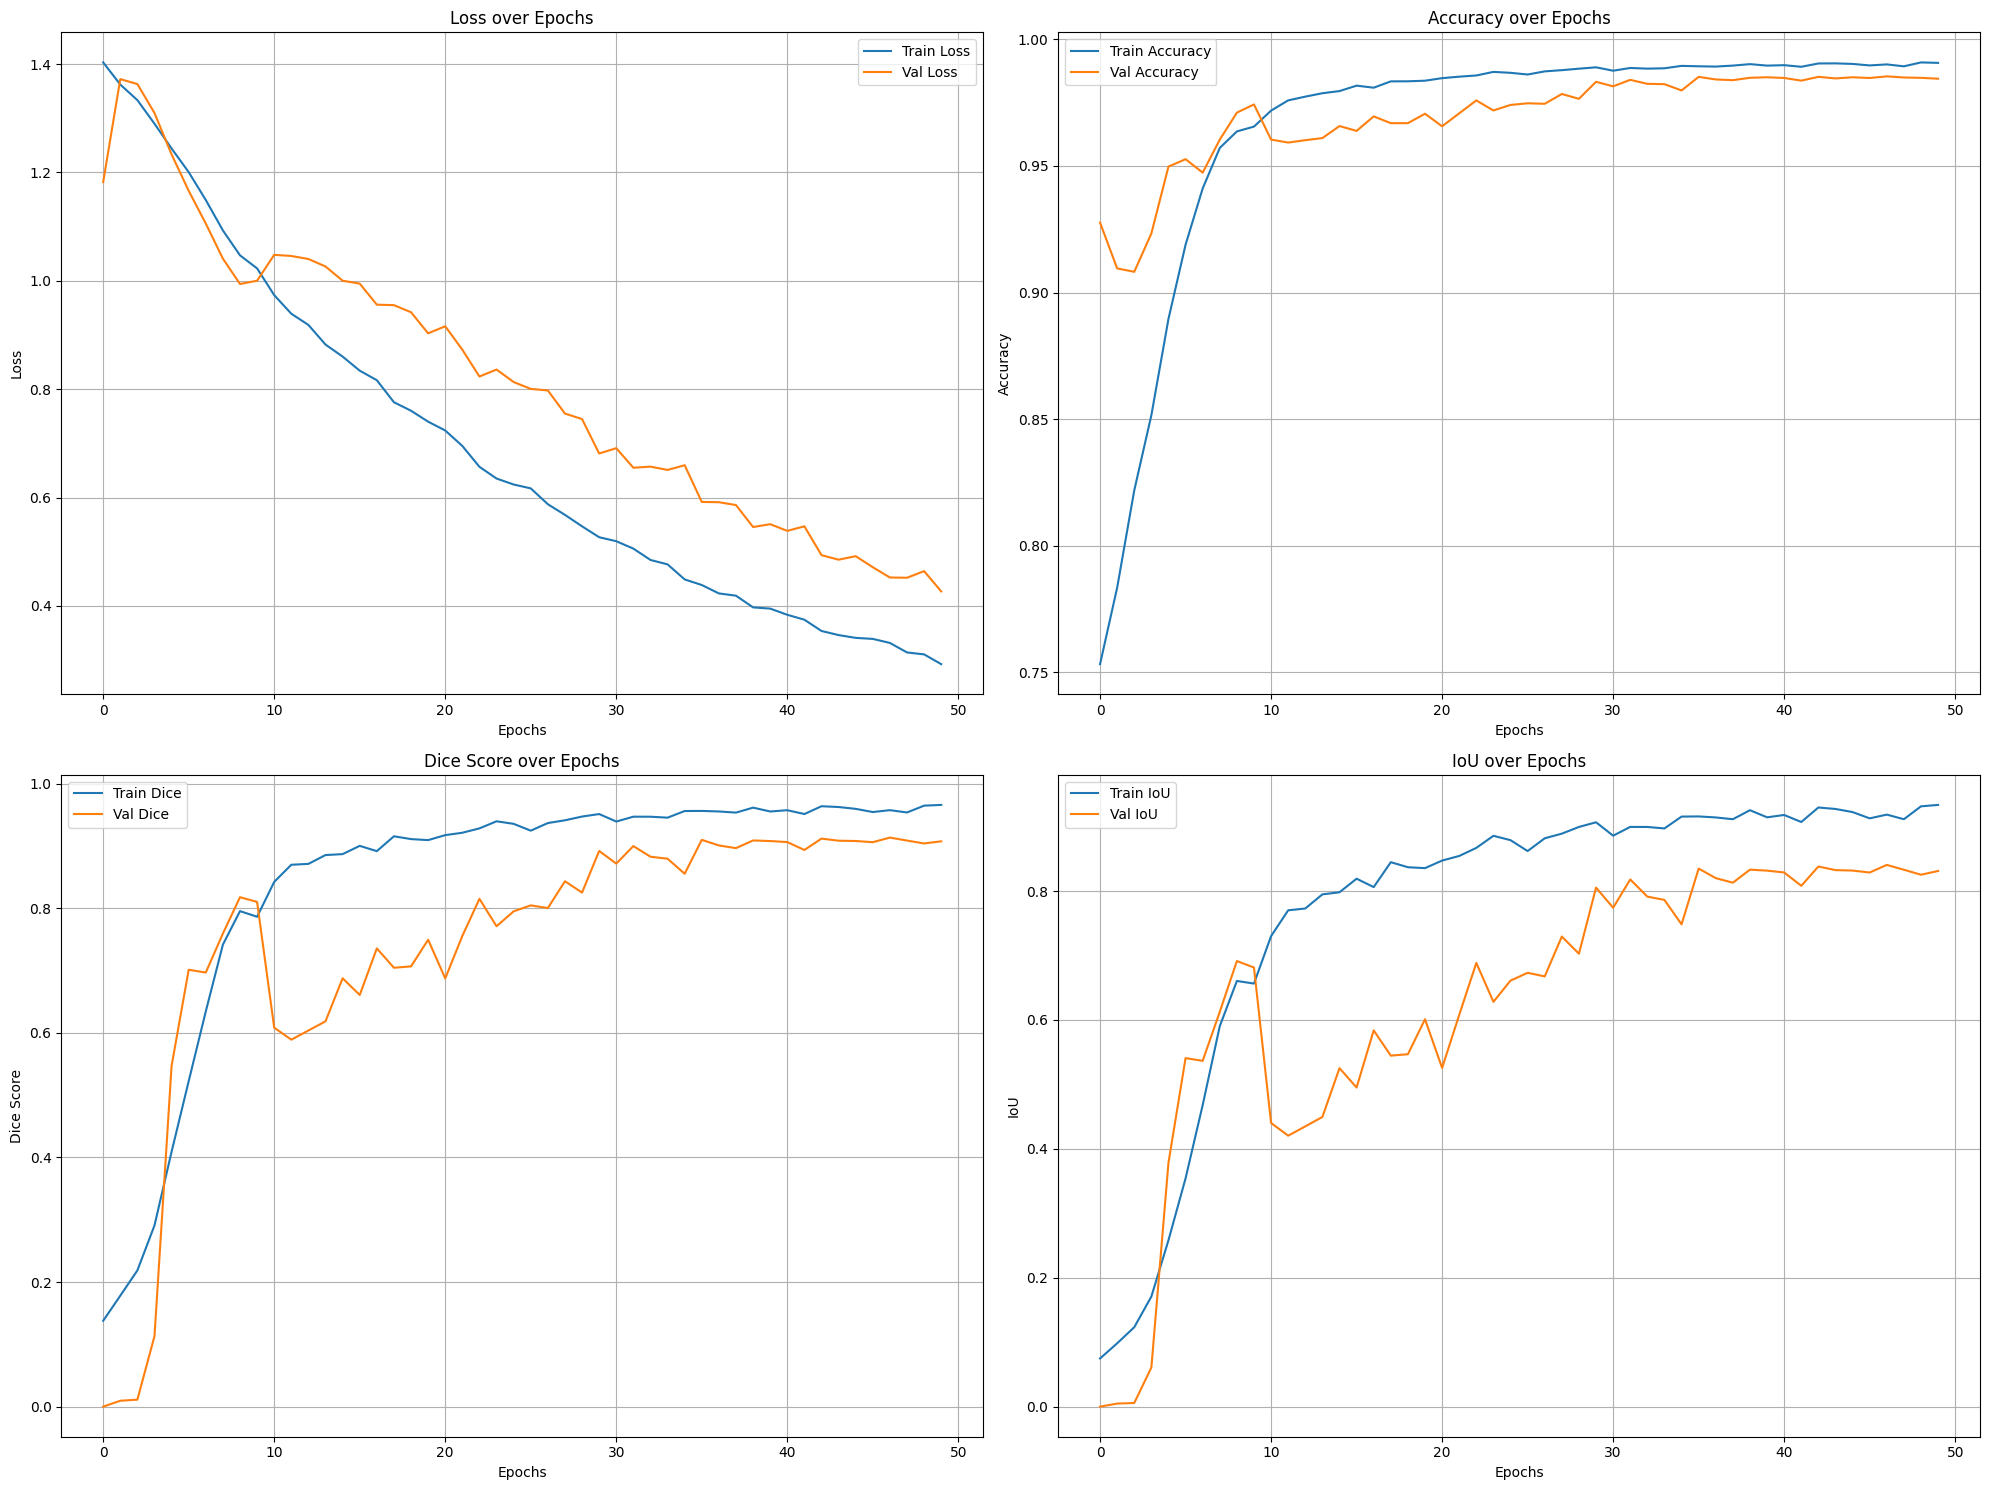

In [24]:
def plot_loss_curves(results):
    """
    Plots training and validation metrics: loss, accuracy, Dice score, and IoU
    from a results dictionary.

    Args:
        results (dict): Dictionary containing lists for each metric per epoch.
                        Keys:
                        - "train_loss", "val_loss"
                        - "train_acc", "val_acc"
                        - "train_dice", "val_dice"
                        - "train_iou", "val_iou"
    """
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(20, 15))

    # 1. Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, results["train_loss"], label="Train Loss")
    plt.plot(epochs, results["val_loss"], label="Val Loss")
    plt.title("Loss over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 2. Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, results["train_acc"], label="Train Accuracy")
    plt.plot(epochs, results["val_acc"], label="Val Accuracy")
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # 3. Dice Score
    plt.subplot(2, 2, 3)
    plt.plot(epochs, results["train_dice"], label="Train Dice")
    plt.plot(epochs, results["val_dice"], label="Val Dice")
    plt.title("Dice Score over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Dice Score")
    plt.legend()
    plt.grid(True)

    # 4. IoU
    plt.subplot(2, 2, 4)
    plt.plot(epochs, results["train_iou"], label="Train IoU")
    plt.plot(epochs, results["val_iou"], label="Val IoU")
    plt.title("IoU over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_loss_curves(model_0_results)

## Results on test_set (Ground Truth vs Predicted masks)


🔍 Inference for image 1


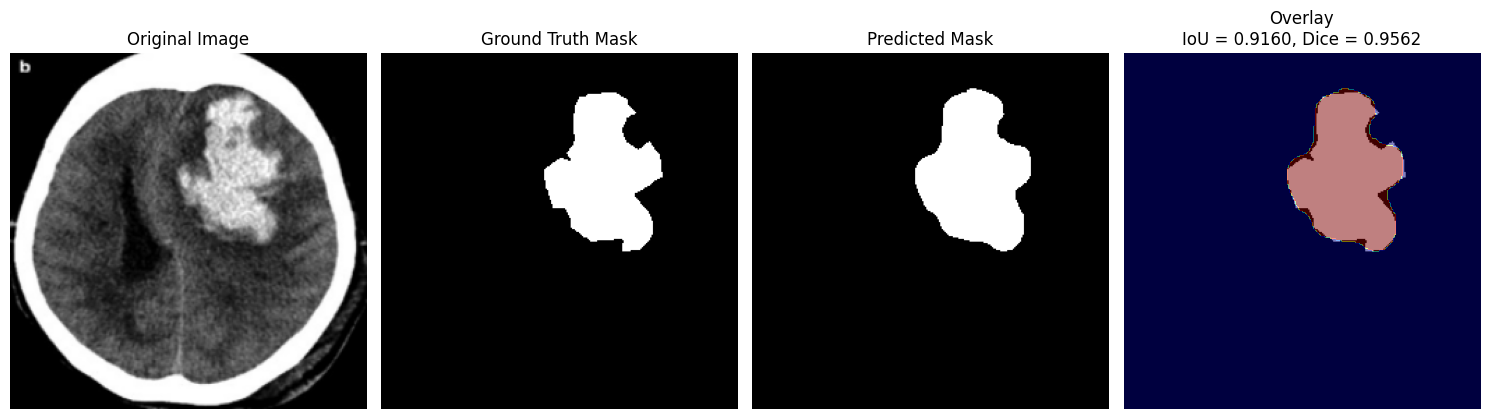


🔍 Inference for image 2


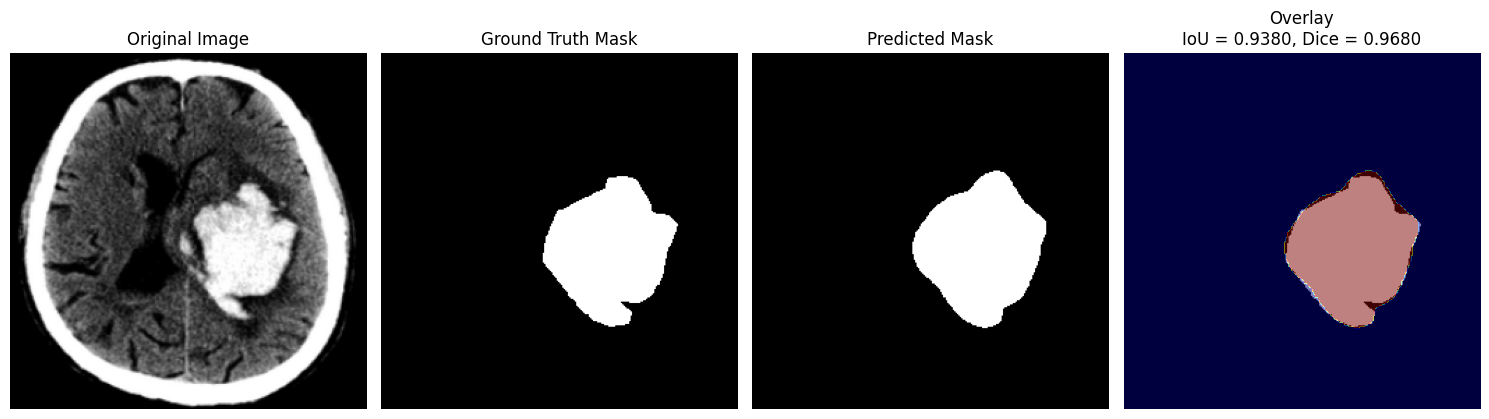


🔍 Inference for image 3


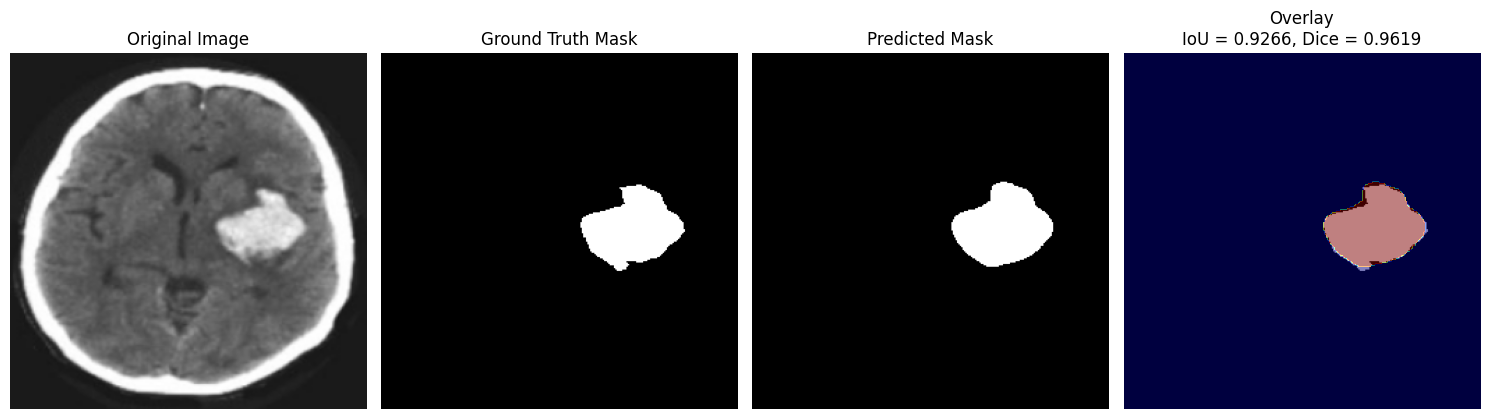


🔍 Inference for image 4


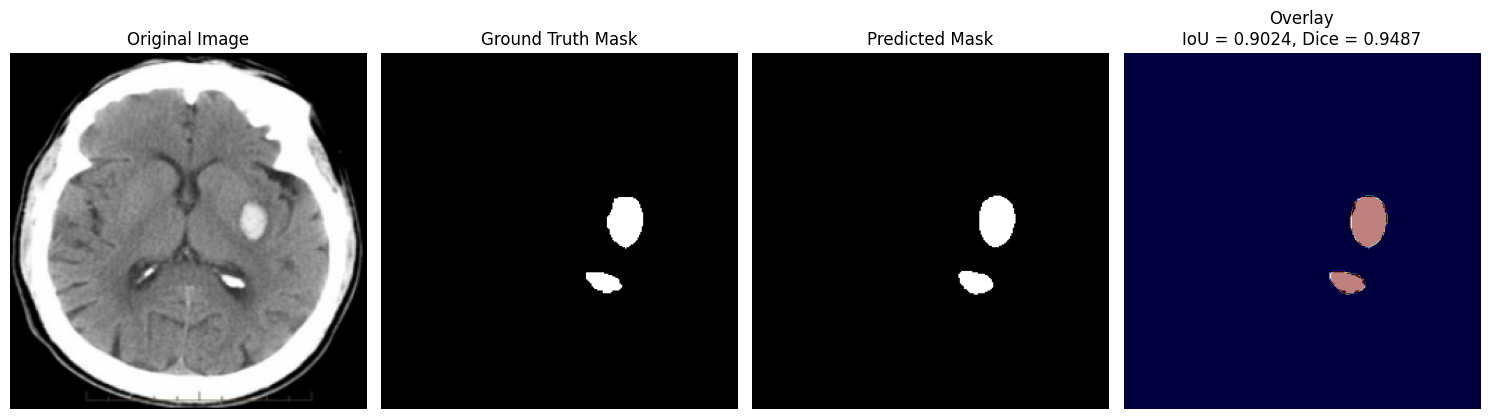


🔍 Inference for image 5


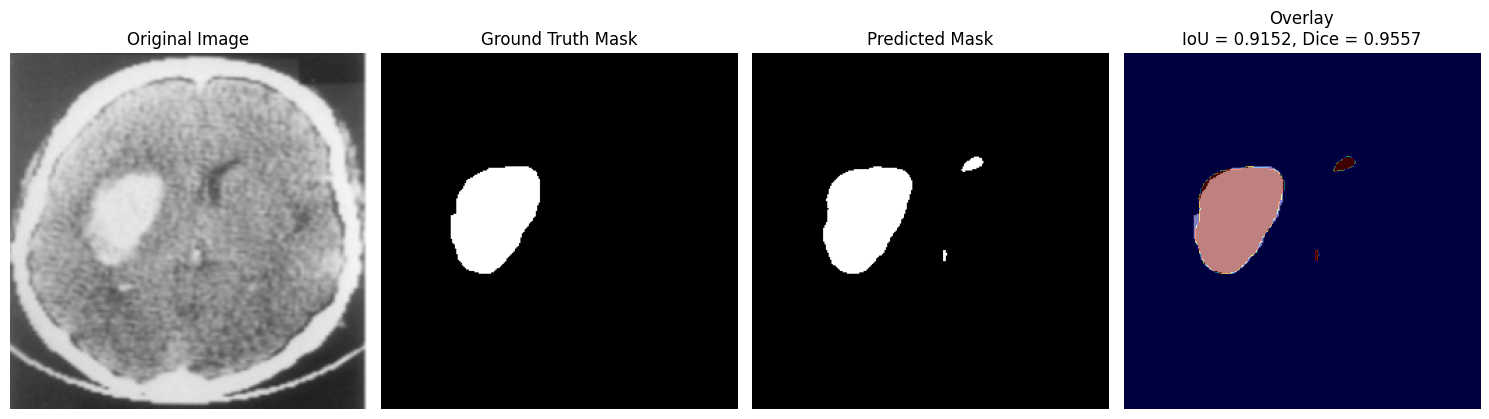


🔍 Inference for image 6


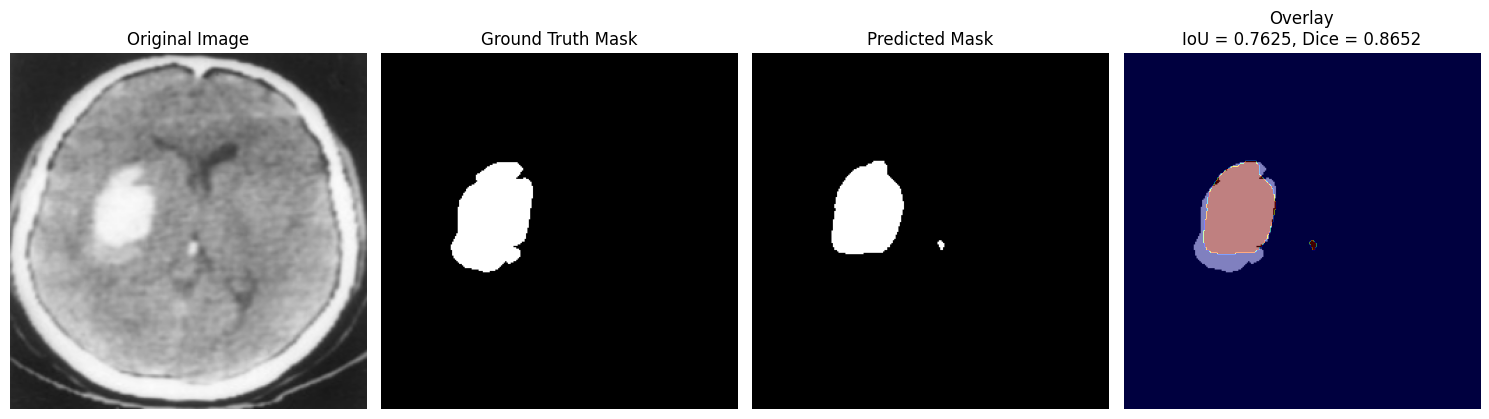


🔍 Inference for image 7


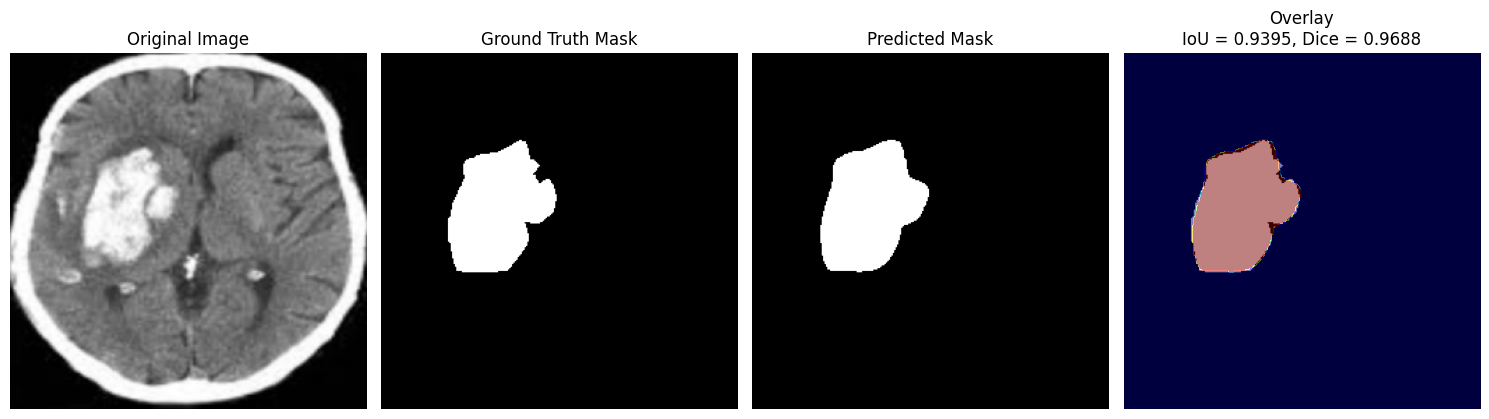


🔍 Inference for image 8


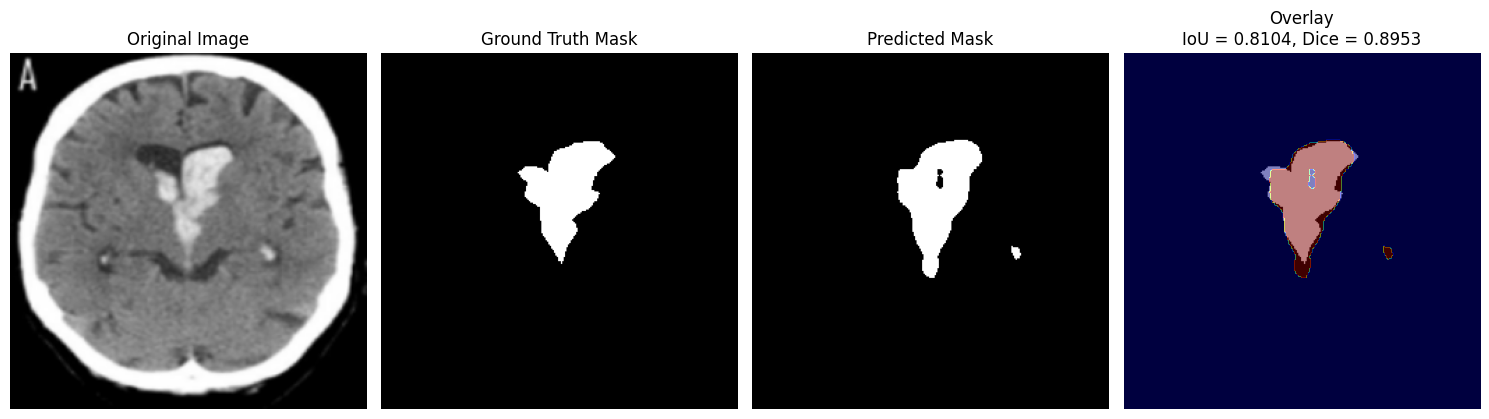


🔍 Inference for image 9


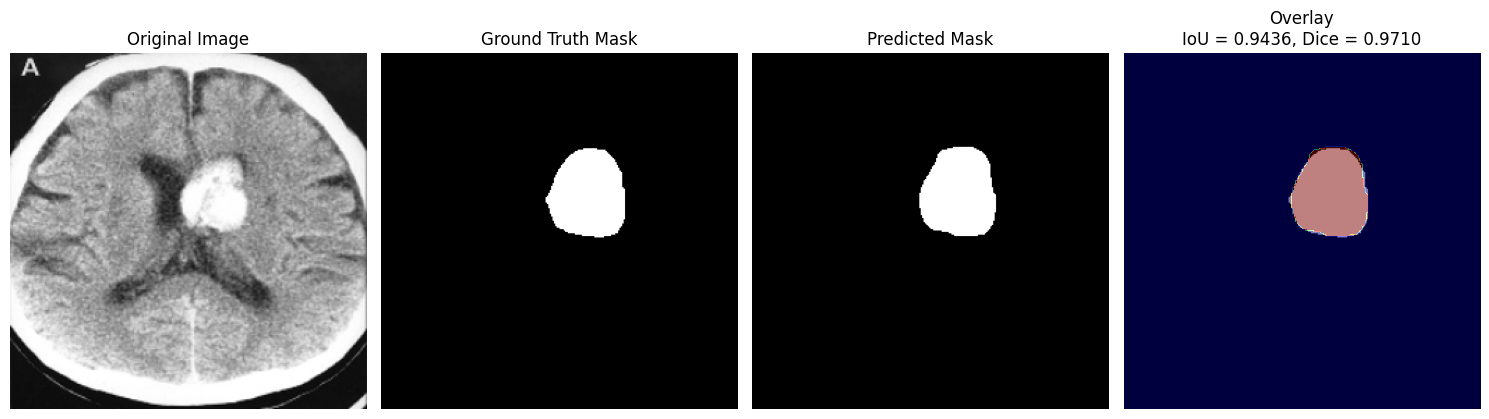


🔍 Inference for image 10


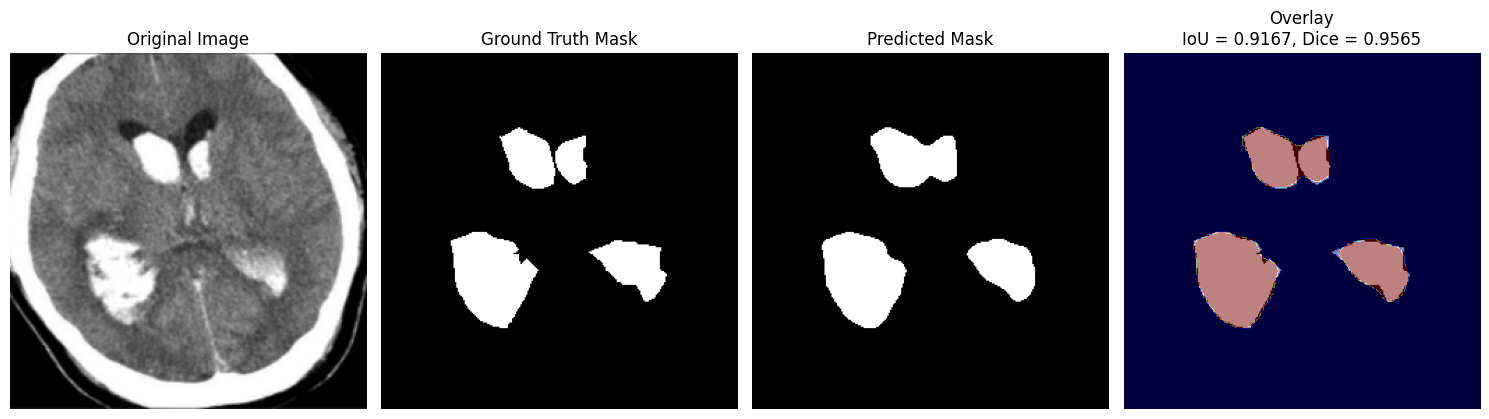


📊 Per-image Evaluation Metrics:


,Image,IoU,Dice,Precision,Recall,F1-Score
0,Image_1,0.916047,0.956184,0.924930,0.989625,0.956184
1,Image_2,0.937984,0.968000,0.948681,0.988122,0.968000
2,Image_3,0.926649,0.961928,0.947368,0.976942,0.961928
3,Image_4,0.902394,0.948693,0.919325,0.980000,0.948693
4,Image_5,0.915170,0.955707,0.946957,0.964619,0.955707
5,Image_6,0.762468,0.865227,0.976015,0.777027,0.865227
6,Image_7,0.939538,0.968827,0.958179,0.979714,0.968827
7,Image_8,0.810376,0.895257,0.848315,0.947699,0.895257
8,Image_9,0.943614,0.970989,0.971668,0.970311,0.970989
9,Image_10,0.916680,0.956529,0.938457,0.975311,0.956529



📈 🔁 Average Metrics across all 10 test images:
IoU: 0.8971
Dice: 0.9447
Precision: 0.9380
Recall: 0.9549
F1-Score: 0.9447


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

IMAGE_SIZE = (256, 256)  # Example, change this to your model's input size

def dice_coef(pred, target, smooth=1e-7):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_coef(pred, target, smooth=1e-7):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

model.eval()

# For storing metrics
metrics_list = []

for i in range(10):
    print(f"\n🔍 Inference for image {i+1}")

    # Load image
    img_path = test_df['image_path'].iloc[i]
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMAGE_SIZE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Predict mask
    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
        pred_mask_bin = (pred_mask >= 0.5).astype(np.uint8)

    # Ground truth mask
    mask_path = test_df['mask_path'].iloc[i]
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, IMAGE_SIZE)
    gt_mask_bin = (gt_mask > 127).astype(np.uint8)

    # Flatten
    pred_flat = pred_mask_bin.flatten()
    true_flat = gt_mask_bin.flatten()

    # Metrics
    dice = dice_coef(pred_flat, true_flat)
    iou = iou_coef(pred_flat, true_flat)
    precision = precision_score(true_flat, pred_flat, zero_division=0)
    recall = recall_score(true_flat, pred_flat, zero_division=0)
    f1 = f1_score(true_flat, pred_flat, zero_division=0)

    metrics_list.append({
        "Image": f"Image_{i+1}",
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    # Plot
    plt.figure(figsize=(15, 20))
    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.imshow(pred_mask_bin, cmap='jet', alpha=0.5)
    plt.title(f'Overlay\nIoU = {iou:.4f}, Dice = {dice:.4f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_list)
print("\n📊 Per-image Evaluation Metrics:")
display(metrics_df)

# Print average metrics
mean_metrics = metrics_df.iloc[:, 1:].mean()
print("\n📈 🔁 Average Metrics across all 10 test images:")
for metric, value in mean_metrics.items():
    print(f"{metric}: {value:.4f}")



🔍 Inference for image 1


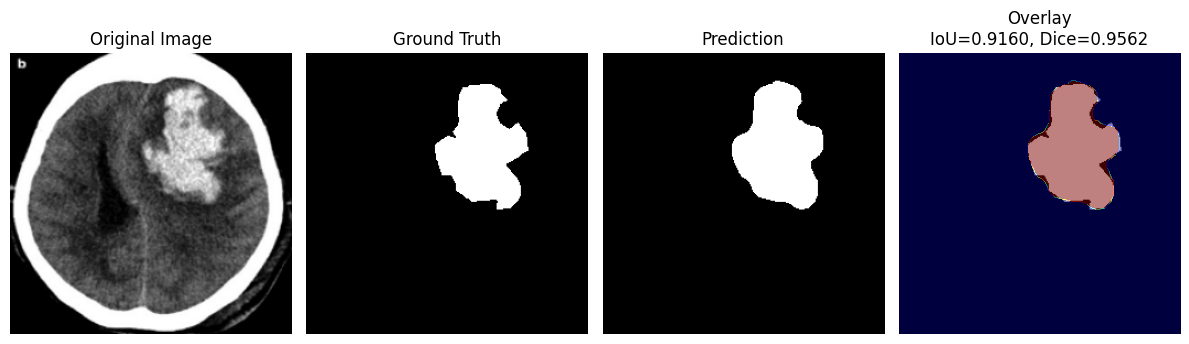


🔍 Inference for image 2


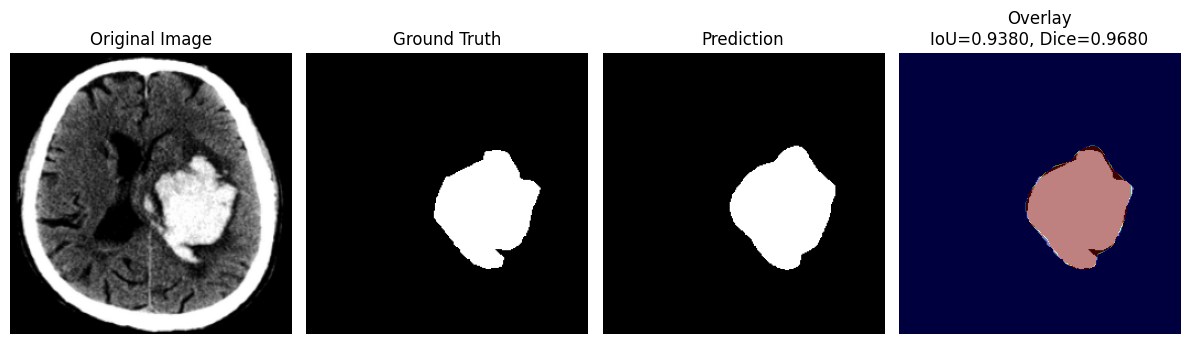


🔍 Inference for image 3


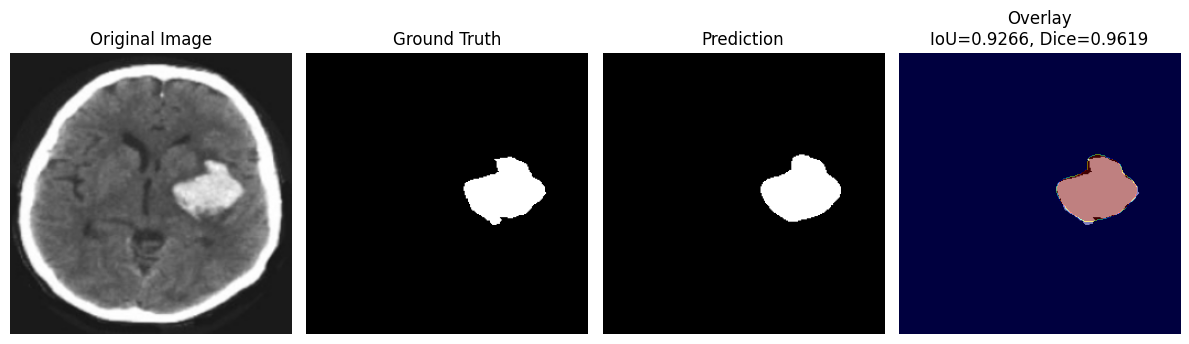


🔍 Inference for image 4


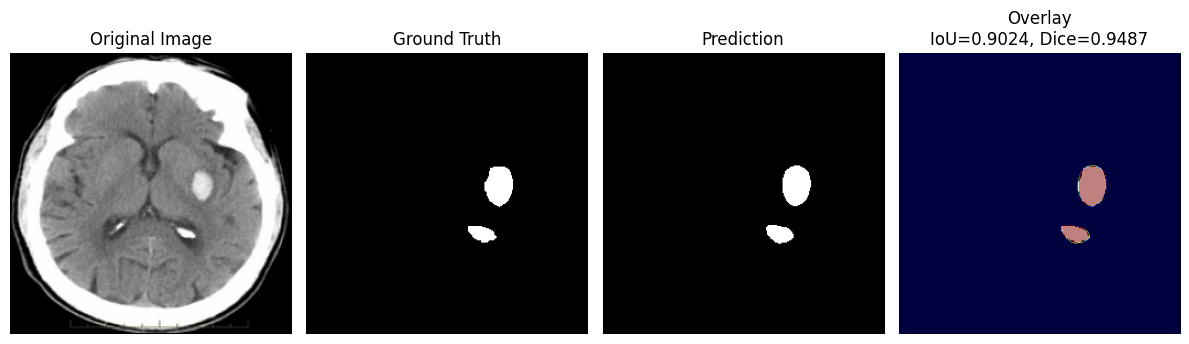


🔍 Inference for image 5


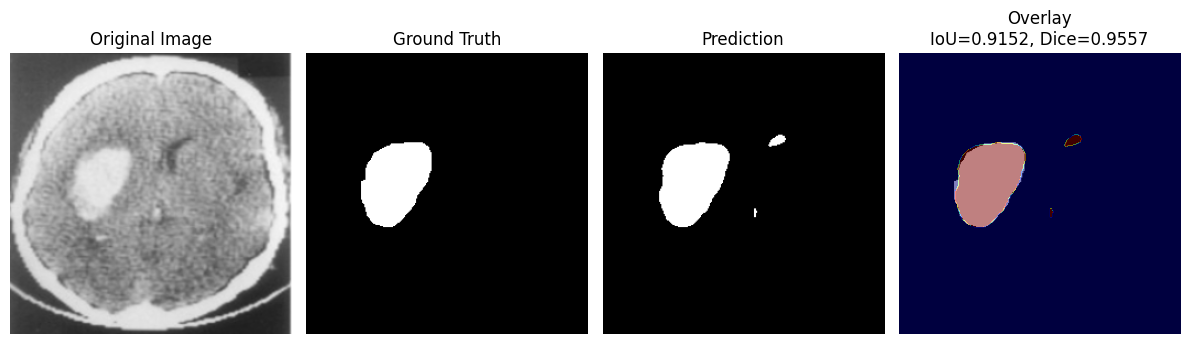


🔍 Inference for image 6


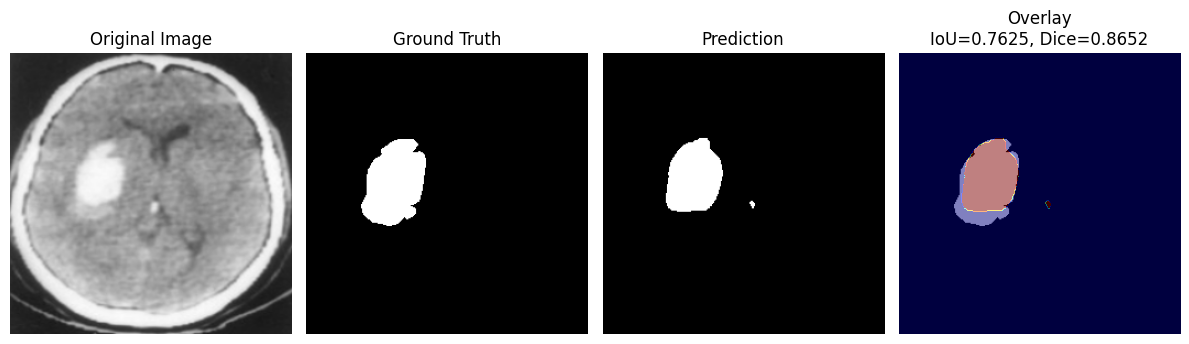


🔍 Inference for image 7


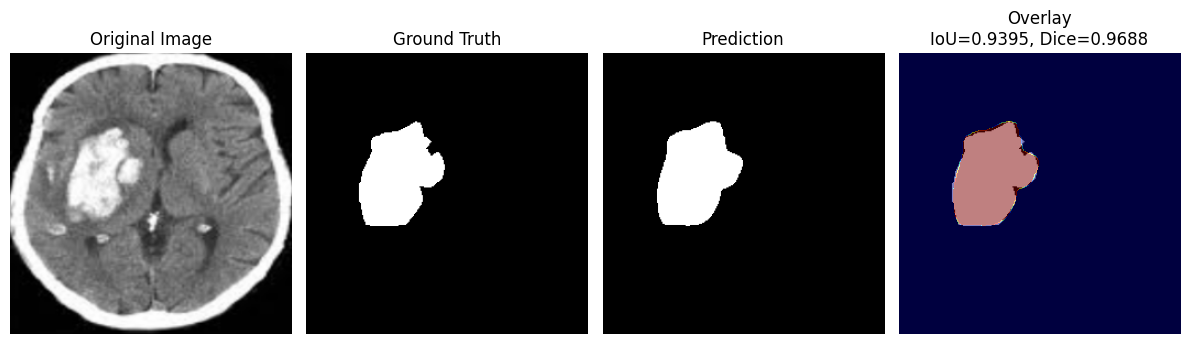


🔍 Inference for image 8


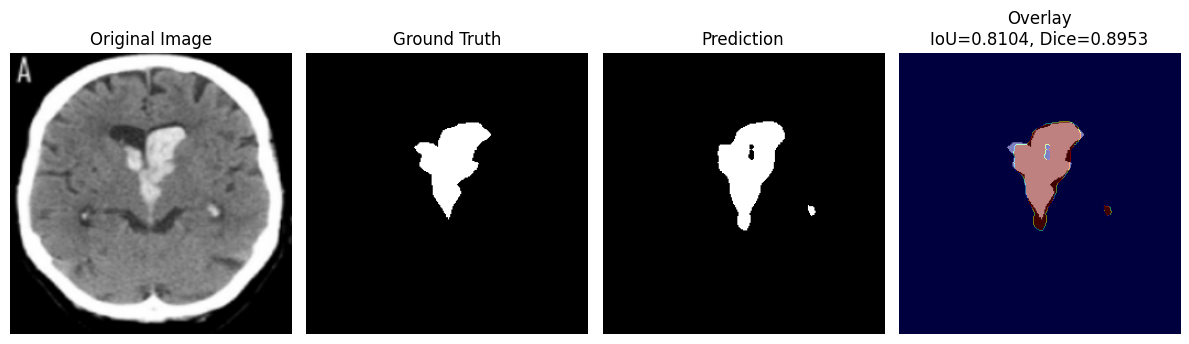


🔍 Inference for image 9


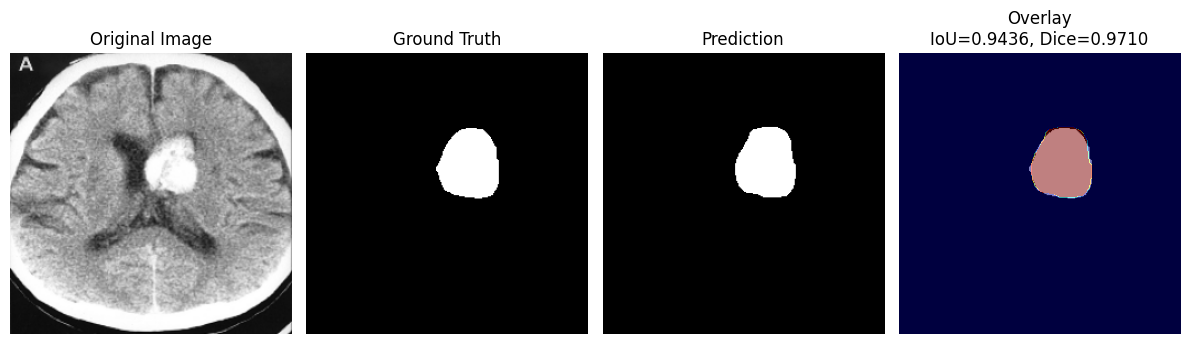


🔍 Inference for image 10


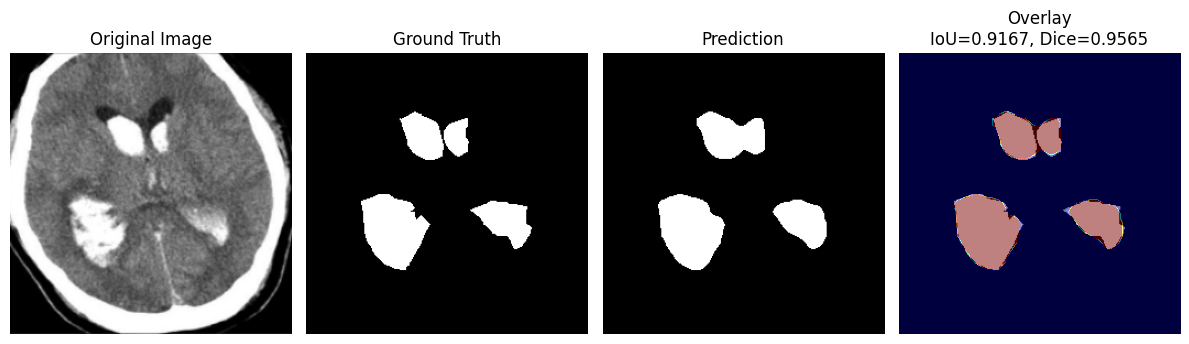


📊 Per-image Evaluation Metrics:


,Image,IoU,Dice,Precision,Recall,F1-Score,Accuracy,Specificity,Balanced Acc,MAE,...,TP,TN,FP,FN,Prec_0,Prec_1,Rec_0,Rec_1,F1_0,F1_1
0,Image_1,0.916047,0.956184,0.924930,0.989625,0.956184,0.991730,0.991941,0.990783,0.248566,...,5914,59080,480,62,0.998952,0.924930,0.991941,0.989625,0.995434,0.956184
1,Image_2,0.937984,0.968000,0.948681,0.988122,0.968000,0.993286,0.993878,0.991000,0.316772,...,6655,58441,360,80,0.998633,0.948681,0.993878,0.988122,0.996250,0.968000
2,Image_3,0.926649,0.961928,0.947368,0.976942,0.961928,0.996674,0.997560,0.987251,0.255249,...,2754,62564,153,65,0.998962,0.947368,0.997560,0.976942,0.998261,0.961928
3,Image_4,0.902394,0.948693,0.919325,0.980000,0.948693,0.998383,0.998667,0.989334,0.079132,...,980,64450,86,20,0.999690,0.919325,0.998667,0.980000,0.999178,0.948693
4,Image_5,0.915170,0.955707,0.946957,0.964619,0.955707,0.995026,0.996817,0.980718,0.504944,...,3517,61693,197,129,0.997913,0.946957,0.996817,0.964619,0.997365,0.955707
5,Image_6,0.762468,0.865227,0.976015,0.777027,0.865227,0.987427,0.998954,0.887990,2.954254,...,2645,62067,65,759,0.987919,0.976015,0.998954,0.777027,0.993406,0.865227
6,Image_7,0.939538,0.968827,0.958179,0.979714,0.968827,0.995163,0.996447,0.988080,0.400162,...,4926,60293,215,102,0.998311,0.958179,0.996447,0.979714,0.997378,0.968827
7,Image_8,0.810376,0.895257,0.848315,0.947699,0.895257,0.990295,0.992245,0.969972,0.591064,...,2718,62182,486,150,0.997594,0.848315,0.992245,0.947699,0.994912,0.895257
8,Image_9,0.943614,0.970989,0.971668,0.970311,0.970989,0.997467,0.998708,0.984509,0.331970,...,2778,62592,81,85,0.998644,0.971668,0.998708,0.970311,0.998676,0.970989
9,Image_10,0.916680,0.956529,0.938457,0.975311,0.956529,0.991837,0.993513,0.984412,0.585648,...,5886,59115,386,149,0.997486,0.938457,0.993513,0.975311,0.995495,0.956529



📈 🔁 Average Metrics across all 10 test images:
IoU: 0.8971
Dice: 0.9447
Precision: 0.9380
Recall: 0.9549
F1-Score: 0.9447
Accuracy: 0.9937
Specificity: 0.9959
Balanced Acc: 0.9754
MAE: 0.6268
MSE: 0.0063
Hausdorff: 3.1492
Boundary F1: 0.2467
TP: 3877.3000
TN: 61247.7000
FP: 250.9000
FN: 160.1000
Prec_0: 0.9974
Prec_1: 0.9380
Rec_0: 0.9959
Rec_1: 0.9549
F1_0: 0.9966
F1_1: 0.9447


In [26]:
import numpy as np
import cv2
import torch
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    balanced_accuracy_score, confusion_matrix,
    mean_absolute_error, mean_squared_error
)
from scipy.spatial.distance import directed_hausdorff
from skimage.segmentation import find_boundaries
import matplotlib.pyplot as plt
import pandas as pd
from torchvision import transforms

IMAGE_SIZE = (256, 256)

def dice_coef(pred, target, smooth=1e-7):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_coef(pred, target, smooth=1e-7):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Image transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

model.eval()
metrics_list = []

for i in range(10):
    print(f"\n🔍 Inference for image {i+1}")

    # Load and preprocess image
    img_path = test_df['image_path'].iloc[i]
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMAGE_SIZE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Predict mask
    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
        pred_mask_bin = (pred_mask >= 0.5).astype(np.uint8)

    # Load ground truth
    mask_path = test_df['mask_path'].iloc[i]
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, IMAGE_SIZE)
    gt_mask_bin = (gt_mask > 127).astype(np.uint8)

    # Flatten
    pred_flat = pred_mask_bin.flatten()
    true_flat = gt_mask_bin.flatten()

    # Metrics
    dice = dice_coef(pred_flat, true_flat)
    iou = iou_coef(pred_flat, true_flat)
    precision = precision_score(true_flat, pred_flat, zero_division=0)
    recall = recall_score(true_flat, pred_flat, zero_division=0)
    f1 = f1_score(true_flat, pred_flat, zero_division=0)
    accuracy = accuracy_score(true_flat, pred_flat)
    balanced_acc = balanced_accuracy_score(true_flat, pred_flat)
    mae = mean_absolute_error(true_flat, pred_flat)
    mse = mean_squared_error(true_flat, pred_flat)

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(true_flat, pred_flat, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp + 1e-7)  # Avoid divide-by-zero

    # Hausdorff distance
    hausdorff = directed_hausdorff(gt_mask_bin, pred_mask_bin)[0]

    # Boundary F1 Score
    gt_boundary = find_boundaries(gt_mask_bin, mode='outer')
    pred_boundary = find_boundaries(pred_mask_bin, mode='outer')
    boundary_f1 = f1_score(gt_boundary.flatten(), pred_boundary.flatten(), zero_division=0)

    # Per-class metrics (binary)
    precision_per_class = precision_score(true_flat, pred_flat, average=None, zero_division=0)
    recall_per_class = recall_score(true_flat, pred_flat, average=None, zero_division=0)
    f1_per_class = f1_score(true_flat, pred_flat, average=None, zero_division=0)

    # Store all metrics
    metrics_list.append({
        "Image": f"Image_{i+1}",
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Accuracy": accuracy,
        "Specificity": specificity,
        "Balanced Acc": balanced_acc,
        "MAE": mae,
        "MSE": mse,
        "Hausdorff": hausdorff,
        "Boundary F1": boundary_f1,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Prec_0": precision_per_class[0], "Prec_1": precision_per_class[1],
        "Rec_0": recall_per_class[0], "Rec_1": recall_per_class[1],
        "F1_0": f1_per_class[0], "F1_1": f1_per_class[1],
    })

    # Visualization
    plt.figure(figsize=(12, 15))  # Reduced width
    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title('Prediction')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.imshow(pred_mask_bin, cmap='jet', alpha=0.5)
    plt.title(f'Overlay\nIoU={iou:.4f}, Dice={dice:.4f}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Display per-image metrics
print("\n📊 Per-image Evaluation Metrics:")
display(metrics_df)

# Display average metrics
mean_metrics = metrics_df.drop(columns=['Image']).mean()
print("\n📈 🔁 Average Metrics across all 10 test images:")
for metric, value in mean_metrics.items():
    print(f"{metric}: {value:.4f}")
